In [41]:
import yfinance as yf
import numpy as np

df = yf.download("GBPUSD=X", start="2000-01-01", auto_adjust=True, interval = "1d")
returns = np.log(df["Close"] / df["Close"].shift(1)).dropna()

print(f"Mean abs daily return: {returns.abs().mean()}")
print(f"Std of daily returns:  {returns.std()}")
print(f"25th percentile abs:   {returns.abs().quantile(0.25)}")
print(f"75th percentile abs:   {returns.abs().quantile(0.75)}")

[*********************100%***********************]  1 of 1 completed

Mean abs daily return: Ticker
GBPUSD=X    0.004231
dtype: float64
Std of daily returns:  Ticker
GBPUSD=X    0.005843
dtype: float64
25th percentile abs:   Ticker
GBPUSD=X    0.00147
Name: 0.25, dtype: float64
75th percentile abs:   Ticker
GBPUSD=X    0.005768
Name: 0.75, dtype: float64


In [33]:
df.head(10)

Price,Close,High,Low,Open,Volume
Ticker,EURJPY=X,EURJPY=X,EURJPY=X,EURJPY=X,EURJPY=X
Datetime,,,,,
2024-06-30 23:00:00+00:00,172.748001,172.759995,172.632004,172.656998,0
2024-07-01 00:00:00+00:00,172.990997,173.218994,172.679001,172.746994,0
2024-07-01 01:00:00+00:00,172.951996,173.167007,172.880997,172.998993,0
2024-07-01 02:00:00+00:00,173.039993,173.044006,172.878006,172.962997,0
2024-07-01 03:00:00+00:00,173.167007,173.203003,173.016006,173.042007,0
2024-07-01 04:00:00+00:00,173.231003,173.255997,173.143997,173.169998,0
2024-07-01 05:00:00+00:00,173.199005,173.317993,173.141998,173.227005,0
2024-07-01 06:00:00+00:00,173.285995,173.470993,173.190994,173.195999,0


In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\Agaba_Embedded4\Desktop\Price prediction-end-to-end\data\features\featured_eurusd.csv")

In [3]:
df.columns

Index(['open', 'high', 'low', 'close', 'volume', 'log_return',
       'next_log_return', 'label', 'body', 'body_abs',
       ...
       'ret_min_30d', 'ret_max_30d', 'pos_days_30d', 'ret_mean_63d',
       'ret_std_63d', 'ret_skew_63d', 'ret_kurt_63d', 'ret_min_63d',
       'ret_max_63d', 'pos_days_63d'],
      dtype='object', length=137)

In [4]:
df["label"]

0      1
1      1
2      1
3      1
4      3
      ..
420    1
421    1
422    1
423    0
424    2
Name: label, Length: 425, dtype: int64

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.preprocessing import MinMaxScaler

def find_predictive_columns(df, target_col, task='regression', top_n=10, impute_strategy='median'):
    """
    Handles missing values and identifies top predictive features using Pearson Correlation and Mutual Information.
    
    Parameters:
    - df: pandas DataFrame
    - target_col: str, the name of the target column
    - task: 'regression' or 'classification'
    - top_n: int, number of top features to return
    - impute_strategy: 'median' or 'mean' for filling NaN values in features
    
    Returns:
    - A DataFrame with features ranked by their combined predictive score.
    """
    # 1. Handle NaNs in the target column (drop rows where target is missing)
    df_clean = df.dropna(subset=[target_col]).copy()
    
    if df_clean.empty:
        raise ValueError("All rows contain NaN in the target column.")

    # Separate features and target
    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col]
    
    # Keep only numeric columns for this mathematical analysis
    X_numeric = X.select_dtypes(include=[np.number]).copy()
    
    if X_numeric.shape[1] == 0:
        raise ValueError("No numeric columns found in the DataFrame to analyze.")
        
    # 2. Handle NaNs in the feature columns using imputation
    if impute_strategy == 'median':
        X_numeric = X_numeric.fillna(X_numeric.median())
    elif impute_strategy == 'mean':
        X_numeric = X_numeric.fillna(X_numeric.mean())
    else:
        raise ValueError("impute_strategy must be either 'median' or 'mean'")
        
    # 3. Pearson Correlation
    correlations = X_numeric.corrwith(y).abs().fillna(0)
    
    # 4. Mutual Information
    if task == 'regression':
        mi_scores = mutual_info_regression(X_numeric, y, random_state=42)
    elif task == 'classification':
        mi_scores = mutual_info_classif(X_numeric, y, random_state=42)
    else:
        raise ValueError("Task must be either 'regression' or 'classification'")
        
    mi_series = pd.Series(mi_scores, index=X_numeric.columns)
    
    # 5. Combine and Normalize Scores (0 to 1 scale)
    scaler = MinMaxScaler()
    
    corr_scaled = scaler.fit_transform(correlations.values.reshape(-1, 1)).flatten()
    mi_scaled = scaler.fit_transform(mi_series.values.reshape(-1, 1)).flatten()
    
    # Create results DataFrame
    results = pd.DataFrame({
        'Pearson_Corr': correlations,
        'Mutual_Info': mi_series,
        'Combined_Score': (corr_scaled + mi_scaled) / 2
    }, index=X_numeric.columns)
    
    # Sort by the combined score
    results = results.sort_values(by='Combined_Score', ascending=False)
    
    return results.head(top_n)


def plot_predictive_columns(results_df, output_filename='predictive_features.png'):
    """
    Creates a horizontal bar chart comparing Pearson Correlation, Mutual Information, 
    and the Combined Score for the top features.
    
    Parameters:
    - results_df: DataFrame returned by find_predictive_columns
    - output_filename: str, filename to save the generated plot
    """
    # Sort ascending for a clean top-to-bottom horizontal bar chart representation
    plot_data = results_df.sort_values(by='Combined_Score', ascending=True)
    
    # Generate the multi-bar horizontal chart
    ax = plot_data.plot(
        kind='barh', 
        y=['Pearson_Corr', 'Mutual_Info', 'Combined_Score'], 
        colormap='viridis',
        width=0.8
    )
    
    # Customize titles and labels
    ax.set_title('Top Predictive Features (Pearson vs. Mutual Information)', fontsize=14, pad=15)
    ax.set_xlabel('Score / Value', fontsize=12)
    ax.set_ylabel('Features', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Place legend outside or neatly inside
    ax.legend(['Pearson Corr (Abs)', 'Mutual Information', 'Combined Score (Scaled)'], loc='lower right')
    
    # Adjust layout to prevent truncation of long feature names
    plt.tight_layout()
    
    # Save the plot
    plt.savefig(output_filename, dpi=300)
    print(f"Plot successfully saved to {output_filename}")

In [14]:
top_features = find_predictive_columns(df, target_col='label', task='regression', top_n=15)

c:\Users\Agaba_Embedded4\Desktop\Price prediction-end-to-end\penv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Agaba_Embedded4\Desktop\Price prediction-end-to-end\penv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [15]:
top_features

,Pearson_Corr,Mutual_Info,Combined_Score
next_log_return,0.902924,1.475358,1.000000
lower_wick_pct,0.710294,0.332531,0.506025
upper_wick_pct,0.709237,0.298705,0.493976
wick_upper,0.624058,0.328097,0.456769
wick_lower,0.600180,0.296368,0.432793
plus_di,0.181944,0.056187,0.119795
stoch_k,0.160144,0.089806,0.119116
williams_r,0.160144,0.079713,0.115695
range,0.121101,0.134281,0.112568
di_diff,0.173107,0.006370,0.098018


Plot successfully saved to predictive_features.png


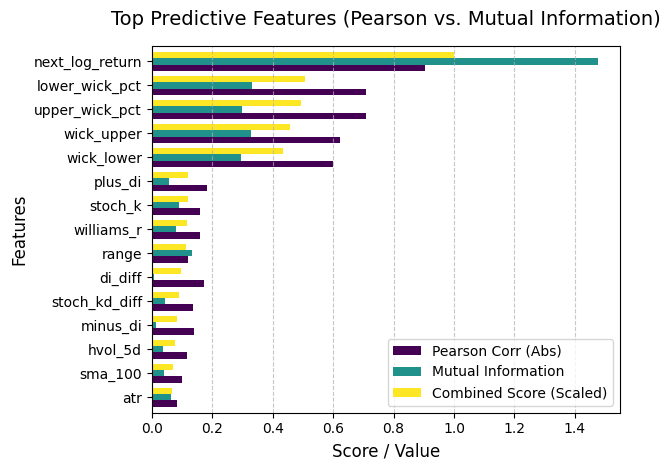

In [16]:
plot_predictive_columns(top_features, output_filename='predictive_features.png')

In [19]:
feature_df = df[top_features.index]

In [31]:
list(top_features.index) + ["label"]

['next_log_return',
 'lower_wick_pct',
 'upper_wick_pct',
 'wick_upper',
 'wick_lower',
 'plus_di',
 'stoch_k',
 'williams_r',
 'range',
 'di_diff',
 'stoch_kd_diff',
 'minus_di',
 'hvol_5d',
 'sma_100',
 'atr',
 'label']

In [26]:
a = [1,2,3,4,5]
b = [5,4,3,2,1]

In [27]:
a+b

[1, 2, 3, 4, 5, 5, 4, 3, 2, 1]